<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your placement CSV file.


Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv

Uploaded file: placement_predict_50k Dataset.csv

Dataset loaded successfully!
Dataset shape: (50000, 32)

First 5 rows:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Working dataset shape: (50000, 13)

Missing values after filling:
0

X shape: (50000, 12)
y shape: (50000, 1)

Training data: (40000, 12)
Testing data : (10000, 12)

Feature scaling completed!

X_train_b shape: (40000, 13)
X_test_b shape : (10000, 13)
Batch Gradient Descent completed!
theta_gd shape: (13, 1)
Number of epochs: 500
Batch Gradient Descent completed!
theta_gd shape: (13, 1)
Number of epochs: 500
[Batch GD] Test RMSE = 4.4105
[sklearn LR] Test RMSE = 4.4105
Difference (GD - sklearn) = 0.000000

Mini-Batch Gradient Descent completed!
theta_mb shape: (13, 1)
[Mini-batch GD] Test RMSE = 4.4190


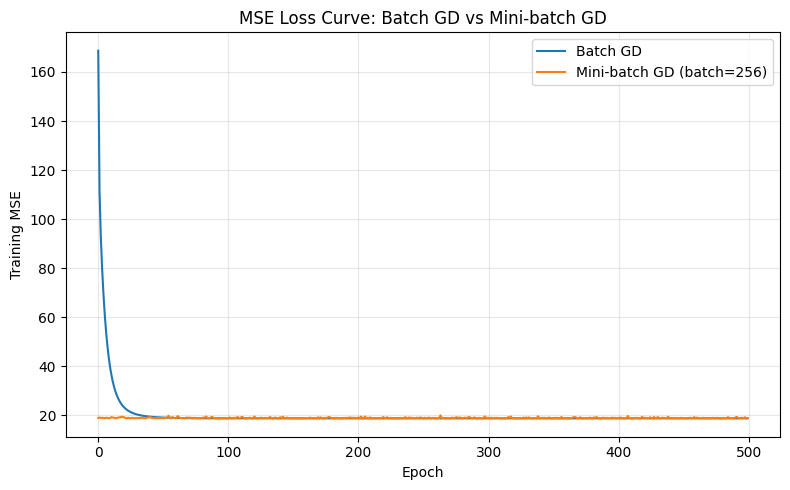


=== RMSE Comparison ===
Method                 Test RMSE
Batch GD                  4.4105
Mini-batch GD             4.4190
sklearn LinearReg         4.4105


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
print("Please upload your placement CSV file.")
uploaded = files.upload()
# Automatically get the uploaded filename
filename = list(uploaded.keys())[0]
print("\nUploaded file:", filename)
df = pd.read_csv(filename)
print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
FEATURES = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

TARGET = "Salary Package"
data = df[FEATURES + [TARGET]].copy()
print("\nWorking dataset shape:", data.shape)
data[FEATURES] = data[FEATURES].fillna(
    data[FEATURES].median()
)
print("\nMissing values after filling:")
print(data[FEATURES].isnull().sum().sum())
X = data[FEATURES].values
y = data[TARGET].values.reshape(-1, 1)
print("\nX shape:", X.shape)
print("y shape:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("\nTraining data:", X_train.shape)
print("Testing data :", X_test.shape)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("\nFeature scaling completed!")
n_samples, n_features = X_train_s.shape
X_train_b = np.hstack([
    np.ones((n_samples, 1)),
    X_train_s
])
X_test_b = np.hstack([
    np.ones((X_test_s.shape[0], 1)),
    X_test_s
])
print("\nX_train_b shape:", X_train_b.shape)
print("X_test_b shape :", X_test_b.shape)
def compute_mse(X, y, theta):
    preds = X @ theta
    errors = preds - y
    return np.mean(errors ** 2)
    def batch_gradient_descent(X, y, lr=0.05, n_epochs=500):
        m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []
    for epoch in range(n_epochs):
        preds = X @ theta
        errors = preds - y
        gradient = (2 / m) * (X.T @ errors)
        theta -= lr * gradient
        loss_history.append(
            compute_mse(X, y, theta)
        )
    return theta, loss_history
m, n = X_train_b.shape
theta_gd = np.zeros((n, 1))
loss_history_gd = []
learning_rate = 0.05
epochs = 500
for epoch in range(epochs):
    # Predictions
    predictions = X_train_b @ theta_gd
    # Errors
    errors = predictions - y_train
    # Gradient
    gradient = (2 / m) * (X_train_b.T @ errors)
    # Update weights
    theta_gd = theta_gd - learning_rate * gradient
    # Store MSE
    loss = np.mean(errors ** 2)
    loss_history_gd.append(loss)
print("Batch Gradient Descent completed!")
print("theta_gd shape:", theta_gd.shape)
print("Number of epochs:", epochs)
m, n = X_train_b.shape
theta_gd = np.zeros((n, 1))
loss_history_gd = []
learning_rate = 0.05
epochs = 500
for epoch in range(epochs):
    predictions = X_train_b @ theta_gd
    errors = predictions - y_train
    gradient = (2 / m) * (X_train_b.T @ errors)
    theta_gd = theta_gd - learning_rate * gradient
    mse = np.mean(errors ** 2)
    loss_history_gd.append(mse)
print("Batch Gradient Descent completed!")
print("theta_gd shape:", theta_gd.shape)
print("Number of epochs:", epochs)
rmse_gd = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_gd
    )
)
print(
    f"[Batch GD] Test RMSE = {rmse_gd:.4f}"
)
sk_model = LinearRegression()

# IMPORTANT:
# Use X_train_s, NOT X_train_b.
# sklearn automatically handles the intercept.

sk_model.fit(
    X_train_s,
    y_train
)

y_pred_sk = sk_model.predict(
    X_test_s
)

rmse_sklearn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_sk
    )
)

print(
    f"[sklearn LR] Test RMSE = {rmse_sklearn:.4f}"
)

print(
    f"Difference (GD - sklearn) = "
    f"{rmse_gd - rmse_sklearn:.6f}"
)
def mini_batch_gradient_descent(
    X,
    y,
    lr=0.05,
    n_epochs=500,
    batch_size=256,
    seed=42
):

    m, n = X.shape

    # Start weights at zero
    theta = np.zeros((n, 1))

    # Store loss
    loss_history = []

    # Random number generator
    rng = np.random.default_rng(seed)

    # Repeat for each epoch
    for epoch in range(n_epochs):

        # Shuffle training data
        indices = rng.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Process small batches
        for start in range(
            0,
            m,
            batch_size
        ):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Predictions
            preds = X_batch @ theta

            # Errors
            errors = preds - y_batch

            # Gradient
            gradient = (
                2 / X_batch.shape[0]
            ) * (
                X_batch.T @ errors
            )

            # Update weights
            theta -= lr * gradient

        # Calculate full training MSE
        loss_history.append(
            compute_mse(
                X,
                y,
                theta
            )
        )

    return theta, loss_history
theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500,
    batch_size=256,
    seed=42
)

print("\nMini-Batch Gradient Descent completed!")

print("theta_mb shape:", theta_mb.shape)
rmse_mb = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_mb
    )
)

print(
    f"[Mini-batch GD] Test RMSE = {rmse_mb:.4f}"
)
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history_gd,
    label="Batch GD"
)

plt.plot(
    loss_history_mb,
    label="Mini-batch GD (batch=256)"
)

plt.xlabel("Epoch")

plt.ylabel("Training MSE")

plt.title(
    "MSE Loss Curve: Batch GD vs Mini-batch GD"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "loss_curve.png",
    dpi=150
)

plt.show()
print("\n=== RMSE Comparison ===")

print(
    f"{'Method':<20}"
    f"{'Test RMSE':>12}"
)

print(
    f"{'Batch GD':<20}"
    f"{rmse_gd:>12.4f}"
)

print(
    f"{'Mini-batch GD':<20}"
    f"{rmse_mb:>12.4f}"
)

print(
    f"{'sklearn LinearReg':<20}"
    f"{rmse_sklearn:>12.4f}"
)
plt.show()